## Intro


Utiliser l'environnement: _py310_fanalysis_


In [2]:
import os


In [1]:
#chargement - index_col = 0 pour indiquer que la colonne n°0 est un label
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fanalysis.ca import CA
import scipy.stats as stats

In [3]:
os.getcwd()

'/home/francesco/Documents/Notebooks/dossier_prosopographie_politique'

In [88]:
file_choice = "data/Behr and Michon 2014 ministres plus haut postes.csv"

file_choice = "data/filieres_etudes.csv"

#file_choice = "data/femmes_ministres.csv"
D = pd.read_csv(file_choice,
                    sep='\t', index_col=0)


<Axes: ylabel='etudes_vs_filiere'>

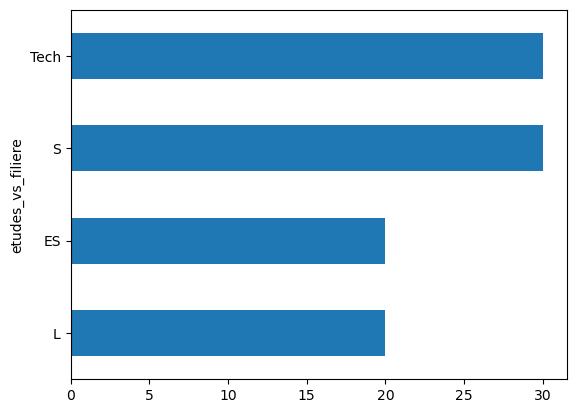

In [89]:
### Distribution par métier
D.sum(axis=1).plot(kind='barh')

<Axes: >

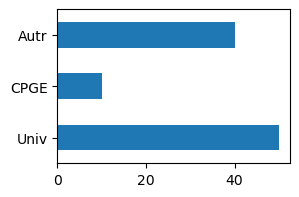

In [90]:
### Distribution par genre et parti politique
D.sum(axis=0).plot(kind='barh', figsize=(3,2))

In [91]:

#affichage des données
print(D)

#nombre de modalités ligne
K = D.shape[0]

#nombre de modalités colonnes
L = D.shape[1]

# Effectif total
n = np.sum(D.values)
# Nombre max. de facteur
Hmax = np.min([K-1,L-1])

print('Dimensions: (', K, ',', L, '), effectif:', n, ', nombre max. facteurs:', Hmax)

                   Univ  CPGE  Autr
etudes_vs_filiere                  
L                    14     2     4
ES                   16     1     3
S                    15     5    10
Tech                  5     2    23
Dimensions: ( 4 , 3 ), effectif: 100 , nombre max. facteurs: 2


In [92]:
### Valeurs produites par une fonction
statistic, p, dof, expected = stats.chi2_contingency(D)

print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)


print('phi2 = inertie (variance totale) :', statistic/n)


### Tableau à l'indépendance
dfe = round(pd.DataFrame(expected),1)

### Coéfficient de Cramer
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html

vc = stats.contingency.association(D, method='cramer')
print('Cramer: ', vc)

Chi2 : 29.574999999999996 , dof : 6
p-value : 4.733757794315464e-05
phi2 = inertie (variance totale) : 0.29574999999999996
Cramer:  0.384545185901475


In [93]:
# Situation d'indépendance
exp_df = pd.DataFrame(expected.round(0).astype(int))
exp_df.index =D.index
exp_df.columns=D.columns
print(exp_df)

                   Univ  CPGE  Autr
etudes_vs_filiere                  
L                    10     2     8
ES                   10     2     8
S                    15     3    12
Tech                 15     3    12


In [96]:

#lancer les calculs
afc = CA(row_labels=D.index,col_labels=D.columns)

In [97]:
afc.fit(D.values)

,n_components,None
,row_labels,"Index(['L', '...s_vs_filiere')"
,col_labels,Index(['Univ'...type='object')
,stats,True


In [ ]:
#propriétés de l'objet
print(dir(afc))

In [42]:
#affichage des valeurs propres
print(afc.eig_)

[[1.52546385e-02 9.81439853e-03]
 [6.08505164e+01 3.91494836e+01]
 [6.08505164e+01 1.00000000e+02]]


In [43]:
#seuil -- moyenne des valeurs propres
meanValPropre = np.mean(afc.eig_[0])
print(meanValPropre)

#ou seuil sur les pourcentages
print(1/Hmax)

0.012534518497078456
0.5


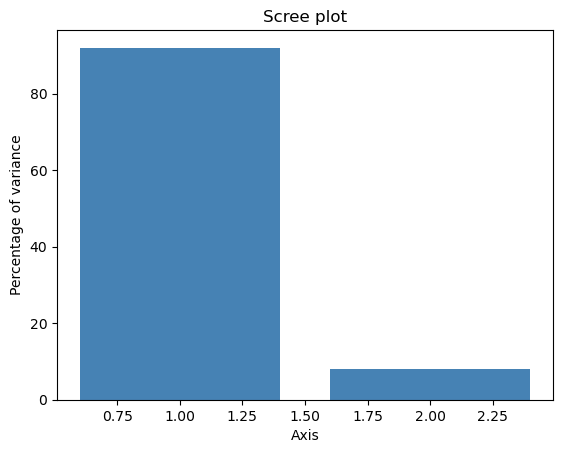

In [102]:
#affichage graphique des v.p.
afc.plot_eigenvalues('percentage')

In [55]:
#informations sur les modalités colonnes
print(afc.col_topandas())

    col_coord_dim1  col_coord_dim2  col_contrib_dim1  col_contrib_dim2  \
FG       -0.174689        0.119141         22.354771         16.162092   
FD        0.145809        0.208391         18.369606         58.321109   
HG        0.128761       -0.077516         34.567026         19.472386   
HD       -0.092724       -0.036785         24.708598          6.044413   

    col_cos2_dim1  col_cos2_dim2  
FG       0.682526       0.317474  
FD       0.328664       0.671336  
HG       0.733985       0.266015  
HD       0.864016       0.135984  


In [83]:
#informations sur les modalités colonnes
afc.row_coord_.T

array([[ 0.19995106, -0.1355607 ,  0.09276698],
       [-0.3101657 , -0.02458205,  0.07011801]])

In [101]:
#informations sur les modalités colonnes
print(afc.col_coord_)

[[-0.48376401 -0.05749537]
 [-0.06850019  0.46040677]
 [ 0.62183006 -0.04323248]]


In [78]:
## transposé
afc.col_coord_.T

array([[-0.17468937,  0.14580912,  0.12876066, -0.09272397],
       [ 0.11914094,  0.20839079, -0.07751623, -0.03678544]])

In [66]:
#informations sur les modalités lignes
print(afc.row_topandas())

                                       row_coord_dim1  row_coord_dim2  \
Fonction                                                                
Premier ministre ou ministre d’État          0.199951       -0.310166   
Ministre                                    -0.135561       -0.024582   
Ministre délégué ou secrétaire d’État        0.092767        0.070118   

                                       row_contrib_dim1  row_contrib_dim2  \
Fonction                                                                    
Premier ministre ou ministre d’État           19.525107         73.025036   
Ministre                                      53.157062          2.716864   
Ministre délégué ou secrétaire d’État         27.317831         24.258100   

                                       row_cos2_dim1  row_cos2_dim2  
Fonction                                                             
Premier ministre ou ministre d’État         0.293578       0.706422  
Ministre                              

In [49]:
#profil marginal des modalités lignes
profMargLig = np.sum(D.values,axis=1)/n
print(profMargLig)

[0.07449857 0.44126074 0.48424069]


In [45]:
#profil marginal des modalités colonnes
profMargLig = np.sum(D.values,axis=0)/n
print(profMargLig)

[0.11174785 0.13180516 0.31805158 0.43839542]


In [ ]:
#contributions
contribLig = (np.reshape(profMargLig,(8,1))*afc.row_coord_**2)/afc.eig_[0]*100
print(contribLig)

In [16]:
#distance à l'origine - distance du KHI2
distoLig = np.sum(afc.row_coord_**2,axis=1)
print(distoLig)

[0.17708174 0.11909062 0.04640997 0.08381149 0.1328715  0.14769668
 0.21042075 0.18752298]


In [20]:
#cos2 des lignes
cos2Lig = afc.row_coord_**2/np.reshape(distoLig,(8,1))*100
print(cos2Lig)

[[6.53055942e+01 5.95320012e+00 2.87412057e+01]
 [2.20786198e+01 6.42986057e+01 1.36227745e+01]
 [7.15234027e+01 2.43486096e+01 4.12798776e+00]
 [9.45061008e+01 2.25934448e-02 5.47130573e+00]
 [2.14715396e+01 6.09744351e+01 1.75540253e+01]
 [2.83457413e+01 4.81783323e-01 7.11724754e+01]
 [4.82896847e+01 4.98705579e+01 1.83975746e+00]
 [6.36246121e+01 3.62992724e+01 7.61154807e-02]]


In [ ]:
#statistiques pour les points colonnes
print(afc.col_topandas())

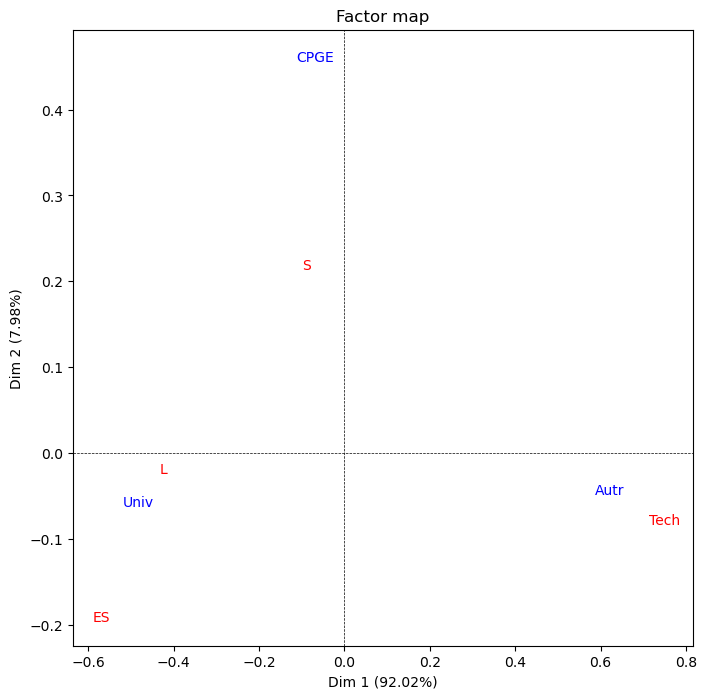

In [99]:
#représentation simultanée
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(8,8))

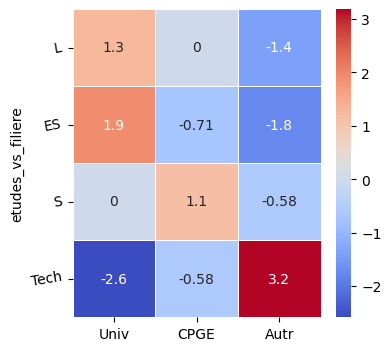

In [100]:
### Résidus pondérés (avec le signe)
### Doc. :
#   Rakotomalala, p.240
residus_ponderes = (round((D.values-dfe)/np.sqrt(dfe),2))
residus_ponderes.columns= D.columns
residus_ponderes.index=D.index


fig, ax = plt.subplots(figsize=(4,4))         
# Sample figsize in inches
g = sns.heatmap(residus_ponderes, annot=residus_ponderes, cmap="coolwarm", linewidths=.5, ax=ax)
labels = residus_ponderes.index
p = g.set_yticklabels(labels, rotation=10)

plt.show()


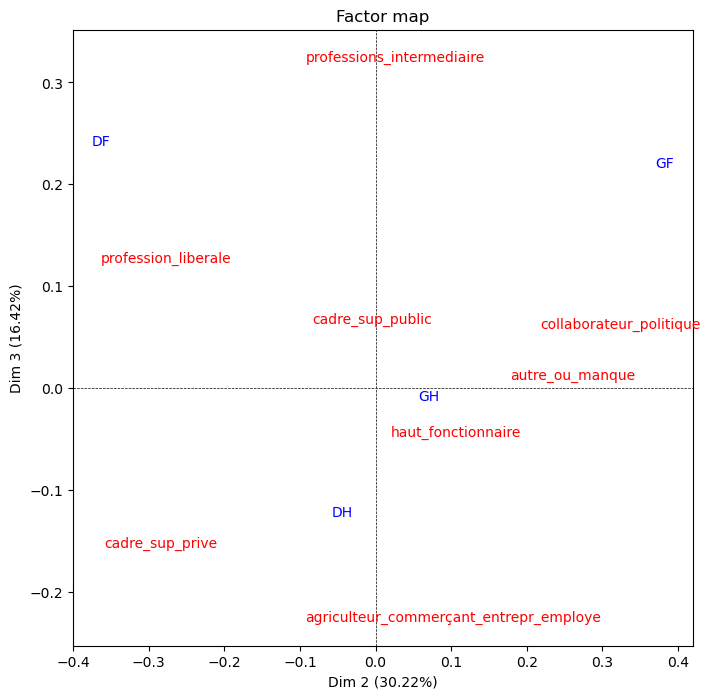

In [24]:
#représentation simultanée
afc.mapping(num_x_axis=2,num_y_axis=3,figsize=(8,8))